# Assignment 1: Foundations & Tensor Operations

**Name:** Hridayanshu Raj Acharya  
**ID:** 032280-22  
**Date:** 2026-04-02  
**Dataset:** Iris (UCI Machine Learning Repository, via `sklearn.datasets.load_iris`)

## Objective
- To understand tensor creation, reshaping and broadcasting.
- To perform core **linear algebra** operations: matrix multiplication, dot products, and eigenvalue decomposition.
- To explore **probability concepts** including entropy, variance, covariance, pca.
- To compare Manual (NumPy) and library (PyTorch) operations.
- To analyze numerical precision issues in computations.

## Theoretical Background

### Tensors
A tensor is a generalisation of scalars, vectors, and matrices to arbitrary dimensions (rank).
- Rank-0: scalar · Rank-1: vector · Rank-2: matrix · Rank-n: n-dimensional array.
- **Reshaping** rearranges elements without copying data, provided total element count is preserved.
- **Broadcasting** lets NumPy/PyTorch implicitly expand smaller tensors along size-1 dimensions so element-wise operations work without explicit replication.

### Dot Product
The dot product of two vectors produces a scalar by multiplying corresponding elements and summing the results. It measures the similarity between two samples, a higher value indicates the vectors point in a similar direction. It is the fundamental operation underlying every matrix multiplication in neural networks.

### Linear Algebra
**Matrix multiplication** (A @ B): rows of A dotted with columns of B. For an (m×k) and (k×n) matrix the result is (m×n). In ML, this operation represents a linear transformation, projecting data from one space into another, exactly as a fully connected layer does.

**Covariance matrix** captures how features vary together. A positive value between two features means they increase together; a negative value means they move in opposite directions. The diagonal entries are the variances of individual features.

**Eigendecomposition**: given a square matrix, eigenvalues represent the magnitude of transformation along each direction, and eigenvectors represent those directions themselves. For a covariance matrix, eigenvectors point in the directions of maximum spread in the data.

### Standardization (Z-score Normalization)
Standardization transforms each feature to have zero mean and unit standard deviation. This ensures features with larger scales do not dominate computations like covariance or distance. It is a necessary preprocessing step before PCA and many ML algorithms.

### PCA 
Eigendecomposition alone does not perform PCA, it must follow a specific sequence: standardize the data, compute the covariance matrix, extract and sort eigenvectors by their eigenvalues, then project the original data onto the top eigenvectors. The projection step transforms high-dimensional data into a lower-dimensional space while retaining the directions of maximum variance.

### Variance
Each eigenvalue represents the amount of variance captured by its corresponding principal component. By expressing each eigenvalue as a proportion of the total sum of eigenvalues, we get the percentage of information retained by each component. Cumulative variance explained is used to decide how many components are sufficient.

### Probability & Entropy
**Shannon entropy** measures uncertainty in a distribution. A uniform distribution (all outcomes equally likely) has maximum entropy. A deterministic distribution (one outcome certain) has zero entropy. In ML, entropy is used in decision tree splits, cross-entropy loss, and information gain during feature selection.

### Discretizing Continuous Distributions
Shannon entropy is defined for probability distributions, not raw continuous values. To apply it to continuous features like Iris measurements, values are grouped into bins (a histogram) and the bin counts are normalized to sum to 1, approximating a discrete probability distribution over value ranges.

### Numerical Precision
Floating-point numbers are stored in finite bits (float32: 23-bit mantissa, float64: 52-bit). Repeated arithmetic accumulates rounding error. **Catastrophic cancellation** occurs when two nearly equal large numbers are subtracted, amplifying relative error. Using higher precision (float64) and numerically stable formulations (e.g., filtering zero probabilities before taking logarithms) mitigates these issues in practice.

## Dataset Description

**Dataset:** Iris (UCI Machine Learning Repository, via `sklearn.datasets.load_iris`)

| Property | Value |
|---|---|
| Samples | 150 |
| Features | 4 (sepal length, sepal width, petal length, petal width) all in cm |
| Classes | 3 (Setosa, Versicolor, Virginica) 50 samples each |
| Missing values | None |
| Data type | Continuous (float64) |


## Implementation

**Imports**

In [1]:
# imports
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import entropy as scipy_entropy
from sklearn.datasets import load_iris

**Loading iris Dataset**

In [2]:
# loading iris dataset
iris = load_iris()

# Extractring the iris data components
iris_data   = iris.data # extracts the data availaible in dataset
iris_target = iris.target # labels for each sample
iris_names  = iris.feature_names # Name of four features
iris_cls    = iris.target_names #  Name of three flower classes

print(f"\nIris dataset loaded: {iris_data.shape[0]} samples, {iris_data.shape[1]} features")
print("Feature names:", iris_names)
print("Class names  :", iris_cls)
print("First 5 rows :\n", iris_data[:5])


Iris dataset loaded: 150 samples, 4 features
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names  : ['setosa' 'versicolor' 'virginica']
First 5 rows :
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


**Creating tensor with manual data**

In [3]:
# A) Tensor creation with manual data
#3 Students with 4 subjects each
manual_data = [ # creating python list for manual student data
    [85.0, 92.0, 78.0, 90.0], # student 1
    [70.0, 65.0, 88.0, 72.0], # student 2
    [95.0, 80.0, 91.0, 85.0], # student 3
]

print("\nA) MANUAL TENSOR (3 students × 4 subjects)")

#Using Numpy
manual_np = np.array(manual_data, dtype=np.float64)
print("Numpy")
print(f"  Shape  : {manual_np.shape}")
print(f"  Dtype  : NumPy={manual_np.dtype}")
print(f"  NumPy  :\n{manual_np}")

#Using pytorch
manual_pt = torch.tensor(manual_data, dtype=torch.float64)
print("Pytorch")
print(f"  Shape  : {manual_pt.shape}")
print(f"  Dtype  : PyTorch={manual_pt.dtype}")
print(f"  PyTorch:\n{manual_pt}")



A) MANUAL TENSOR (3 students × 4 subjects)
Numpy
  Shape  : (3, 4)
  Dtype  : NumPy=float64
  NumPy  :
[[85. 92. 78. 90.]
 [70. 65. 88. 72.]
 [95. 80. 91. 85.]]
Pytorch
  Shape  : torch.Size([3, 4])
  Dtype  : PyTorch=torch.float64
  PyTorch:
tensor([[85., 92., 78., 90.],
        [70., 65., 88., 72.],
        [95., 80., 91., 85.]], dtype=torch.float64)


**Creating tensor with iris dataset**

In [4]:
# B) Tensor creation with iris dataset
#using numpy
dataset_np = iris_data.astype(np.float64) #iris dataset is iteself numpy array, so just ensure float64

#using pytorch
dataset_pt = torch.tensor(iris_data, dtype=torch.float64)# PyTorch

print("\nB) DATASET TENSOR (150 samples × 4 features)")
print(f"  Shape  : {dataset_np.shape}")
print(f"  Dtype  : NumPy={dataset_np.dtype}, PyTorch={dataset_pt.dtype}")
print(f"  NumPy  (first 5 rows):\n{dataset_np[:5]}")
print(f"  PyTorch (first 5 rows):\n{dataset_pt[:5]}")


B) DATASET TENSOR (150 samples × 4 features)
  Shape  : (150, 4)
  Dtype  : NumPy=float64, PyTorch=torch.float64
  NumPy  (first 5 rows):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
  PyTorch (first 5 rows):
tensor([[5.1000, 3.5000, 1.4000, 0.2000],
        [4.9000, 3.0000, 1.4000, 0.2000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        [5.0000, 3.6000, 1.4000, 0.2000]], dtype=torch.float64)


**Tensor utilities**

In [5]:
#tensor utilities
print("  zeros (3×4)  NumPy :", np.zeros((3, 4)))# 3x4 matrix filled with 0 (NumPy)
print("  zeros (3×4)  PyTorch:", torch.zeros(3, 4, dtype=torch.float64))  

print("  ones  (2×3)  NumPy :", np.ones((2, 3)))# 2x3 matrix filled with 1 (NumPy)
print("  ones  (2×3)  PyTorch:", torch.ones(2, 3, dtype=torch.float64))

print("  identity (4) NumPy :", np.eye(4))# 4x4 identity matrix (diagonal = 1)
print("  identity (4) PyTorch:", torch.eye(4, dtype=torch.float64))

print("  random (2×4) NumPy :", np.random.randn(2, 4).round(4))   # random values (normal dist), rounded
print("  random (2×4) PyTorch:", torch.randn(2, 4, dtype=torch.float64).round(decimals=4))

  zeros (3×4)  NumPy : [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
  zeros (3×4)  PyTorch: tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]], dtype=torch.float64)
  ones  (2×3)  NumPy : [[1. 1. 1.]
 [1. 1. 1.]]
  ones  (2×3)  PyTorch: tensor([[1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)
  identity (4) NumPy : [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
  identity (4) PyTorch: tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]], dtype=torch.float64)
  random (2×4) NumPy : [[-0.0784  0.6267 -2.1069  1.7447]
 [-0.6165  0.0126  0.7816  0.0171]]
  random (2×4) PyTorch: tensor([[ 0.4855, -0.5739,  0.1395,  0.9493],
        [-0.1065,  0.1388, -0.6303,  0.9918]], dtype=torch.float64)


**Reshaping** : Flatten

In [6]:
print(f"Original shape: {dataset_np.shape}") #Displays the original shape of the dataset.
# Flatten
flat_np = dataset_np.reshape(-1) #reduces dimensions
flat_pt = dataset_pt.reshape(-1) # automatically calculates original dimension and reduces one step down
print(f"Flatten (600,): {flat_np.shape} | PyTorch: {flat_pt.shape}") #Prints shapes of both NumPy and PyTorch flattened tensors.
print(f"First 5 rows in numpy:\n{flat_np[:5]}") #Displays first 5 elements of the flattened NumPy array.
print(f"First 5 rows in pytorch:\n{flat_pt[:5]}") #Displays first 5 elements of the PyTorch tensor.

Original shape: (150, 4)
Flatten (600,): (600,) | PyTorch: torch.Size([600])
First 5 rows in numpy:
[5.1 3.5 1.4 0.2 4.9]
First 5 rows in pytorch:
tensor([5.1000, 3.5000, 1.4000, 0.2000, 4.9000], dtype=torch.float64)


**Reshaping** : Reshaping to (50, 30, 4)

In [7]:
# Reshape to (50, 3, 4)
'''Reshapes data into a 3D tensor:
50 blocks
each block has 3 samples
each sample has 4 features'''

r1_np = dataset_np.reshape(50, 3, 4) 
r1_pt = dataset_pt.reshape(50, 3, 4)
print(f"\nReshape (50,3,4): {r1_np.shape} | PyTorch: {r1_pt.shape}")#Prints shapes of both tensors after reshaping.
print(f"First 5 rows in numpy:\n{r1_np[:5]}")#Displays first 5 elements along the first dimension of the reshaped NumPy tensor.
print(f"First 5 rows in pytorch:\n{r1_pt[:5]}")#Displays first 5 elements of the PyTorch tensor.


Reshape (50,3,4): (50, 3, 4) | PyTorch: torch.Size([50, 3, 4])
First 5 rows in numpy:
[[[5.1 3.5 1.4 0.2]
  [4.9 3.  1.4 0.2]
  [4.7 3.2 1.3 0.2]]

 [[4.6 3.1 1.5 0.2]
  [5.  3.6 1.4 0.2]
  [5.4 3.9 1.7 0.4]]

 [[4.6 3.4 1.4 0.3]
  [5.  3.4 1.5 0.2]
  [4.4 2.9 1.4 0.2]]

 [[4.9 3.1 1.5 0.1]
  [5.4 3.7 1.5 0.2]
  [4.8 3.4 1.6 0.2]]

 [[4.8 3.  1.4 0.1]
  [4.3 3.  1.1 0.1]
  [5.8 4.  1.2 0.2]]]
First 5 rows in pytorch:
tensor([[[5.1000, 3.5000, 1.4000, 0.2000],
         [4.9000, 3.0000, 1.4000, 0.2000],
         [4.7000, 3.2000, 1.3000, 0.2000]],

        [[4.6000, 3.1000, 1.5000, 0.2000],
         [5.0000, 3.6000, 1.4000, 0.2000],
         [5.4000, 3.9000, 1.7000, 0.4000]],

        [[4.6000, 3.4000, 1.4000, 0.3000],
         [5.0000, 3.4000, 1.5000, 0.2000],
         [4.4000, 2.9000, 1.4000, 0.2000]],

        [[4.9000, 3.1000, 1.5000, 0.1000],
         [5.4000, 3.7000, 1.5000, 0.2000],
         [4.8000, 3.4000, 1.6000, 0.2000]],

        [[4.8000, 3.0000, 1.4000, 0.1000],
         [4

**Reshaping** : Transpose

In [8]:
# Transpose
T_np = dataset_np.T
T_pt = dataset_pt.T
print(f"\nTranspose (4,150): {T_np.shape} | PyTorch: {T_pt.shape}")
print(f"First 5 rows in numpy:\n{T_np[:5]}")
print(f"First 5 rows in pytorch:\n{T_pt[:5]}")


Transpose (4,150): (4, 150) | PyTorch: torch.Size([4, 150])
First 5 rows in numpy:
[[5.1 4.9 4.7 4.6 5.  5.4 4.6 5.  4.4 4.9 5.4 4.8 4.8 4.3 5.8 5.7 5.4 5.1
  5.7 5.1 5.4 5.1 4.6 5.1 4.8 5.  5.  5.2 5.2 4.7 4.8 5.4 5.2 5.5 4.9 5.
  5.5 4.9 4.4 5.1 5.  4.5 4.4 5.  5.1 4.8 5.1 4.6 5.3 5.  7.  6.4 6.9 5.5
  6.5 5.7 6.3 4.9 6.6 5.2 5.  5.9 6.  6.1 5.6 6.7 5.6 5.8 6.2 5.6 5.9 6.1
  6.3 6.1 6.4 6.6 6.8 6.7 6.  5.7 5.5 5.5 5.8 6.  5.4 6.  6.7 6.3 5.6 5.5
  5.5 6.1 5.8 5.  5.6 5.7 5.7 6.2 5.1 5.7 6.3 5.8 7.1 6.3 6.5 7.6 4.9 7.3
  6.7 7.2 6.5 6.4 6.8 5.7 5.8 6.4 6.5 7.7 7.7 6.  6.9 5.6 7.7 6.3 6.7 7.2
  6.2 6.1 6.4 7.2 7.4 7.9 6.4 6.3 6.1 7.7 6.3 6.4 6.  6.9 6.7 6.9 5.8 6.8
  6.7 6.7 6.3 6.5 6.2 5.9]
 [3.5 3.  3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 3.7 3.4 3.  3.  4.  4.4 3.9 3.5
  3.8 3.8 3.4 3.7 3.6 3.3 3.4 3.  3.4 3.5 3.4 3.2 3.1 3.4 4.1 4.2 3.1 3.2
  3.5 3.6 3.  3.4 3.5 2.3 3.2 3.5 3.8 3.  3.8 3.2 3.7 3.3 3.2 3.2 3.1 2.3
  2.8 2.8 3.3 2.4 2.9 2.7 2.  3.  2.2 2.9 2.9 3.1 3.  2.7 2.2 2.5 3.2 2.8
  

**Reshaping** : Adding batch dimension

In [9]:
# Add batch dimension
batch_np = dataset_np[np.newaxis, :] #Adds a new dimension at the beginning.
batch_pt = dataset_pt.unsqueeze(0) #PyTorch equivalent of adding a dimension at position 0.
print(f"Add batch dim (1,150,4): {batch_np.shape} | PyTorch: {batch_pt.shape}") #Prints the new shapes.
print(f"First 5 rows in numpy:\n{batch_np[:5]}") #Displays first 5 elements along the first axis of the batched NumPy array.
print(f"First 5 rows in pytorch:\n{batch_pt[:5]}") #Displays first 5 elements of the batched PyTorch tensor.

Add batch dim (1,150,4): (1, 150, 4) | PyTorch: torch.Size([1, 150, 4])
First 5 rows in numpy:
[[[5.1 3.5 1.4 0.2]
  [4.9 3.  1.4 0.2]
  [4.7 3.2 1.3 0.2]
  [4.6 3.1 1.5 0.2]
  [5.  3.6 1.4 0.2]
  [5.4 3.9 1.7 0.4]
  [4.6 3.4 1.4 0.3]
  [5.  3.4 1.5 0.2]
  [4.4 2.9 1.4 0.2]
  [4.9 3.1 1.5 0.1]
  [5.4 3.7 1.5 0.2]
  [4.8 3.4 1.6 0.2]
  [4.8 3.  1.4 0.1]
  [4.3 3.  1.1 0.1]
  [5.8 4.  1.2 0.2]
  [5.7 4.4 1.5 0.4]
  [5.4 3.9 1.3 0.4]
  [5.1 3.5 1.4 0.3]
  [5.7 3.8 1.7 0.3]
  [5.1 3.8 1.5 0.3]
  [5.4 3.4 1.7 0.2]
  [5.1 3.7 1.5 0.4]
  [4.6 3.6 1.  0.2]
  [5.1 3.3 1.7 0.5]
  [4.8 3.4 1.9 0.2]
  [5.  3.  1.6 0.2]
  [5.  3.4 1.6 0.4]
  [5.2 3.5 1.5 0.2]
  [5.2 3.4 1.4 0.2]
  [4.7 3.2 1.6 0.2]
  [4.8 3.1 1.6 0.2]
  [5.4 3.4 1.5 0.4]
  [5.2 4.1 1.5 0.1]
  [5.5 4.2 1.4 0.2]
  [4.9 3.1 1.5 0.2]
  [5.  3.2 1.2 0.2]
  [5.5 3.5 1.3 0.2]
  [4.9 3.6 1.4 0.1]
  [4.4 3.  1.3 0.2]
  [5.1 3.4 1.5 0.2]
  [5.  3.5 1.3 0.3]
  [4.5 2.3 1.3 0.3]
  [4.4 3.2 1.3 0.2]
  [5.  3.5 1.6 0.6]
  [5.1 3.8 1.9 0.4]
  [4.

**Reshaping** : Restore

In [10]:
# Restore
restored_np = flat_np.reshape(150, 4) #Reshapes the flattened 1D array back into its original 2D shape.
restored_pt = flat_pt.reshape(150, 4)
print(f"Restored match: NumPy={np.allclose(restored_np, dataset_np)} | PyTorch={torch.allclose(restored_pt, dataset_pt)}")

Restored match: NumPy=True | PyTorch=True


**Broadcasting** : Add Scalar

In [11]:
# Add scalar
result_np = dataset_np + 1.0 # Broadcast scalar to all 600 elements
result_pt = dataset_pt + 1.0 # PyTorch broadcasting
print(f"Add scalar 1.0 to all values:")
print(f"    Original first row: {dataset_np[0]}")# Original values
print(f"    After +1 (NumPy): {result_np[0]}")# Each value increased by 1
print(f"    After +1 (PyTorch): {result_pt[0]}")# Same result in PyTorch

Add scalar 1.0 to all values:
    Original first row: [5.1 3.5 1.4 0.2]
    After +1 (NumPy): [6.1 4.5 2.4 1.2]
    After +1 (PyTorch): tensor([6.1000, 4.5000, 2.4000, 1.2000], dtype=torch.float64)


**Broadcasting** : Subtract mean (centering)

In [12]:
# Subtract mean (centering)
mean_np = dataset_np.mean(axis=0) #Mean of each feature (4 values)
mean_pt = dataset_pt.mean(dim=0) #PyTorch mean
centered_np = dataset_np - mean_np #Broadcast (4,) to (150,4)
centered_pt = dataset_pt - mean_pt #PyTorch broadcasting
print(f"Mean centering (subtract feature means):")
print(f"    Feature means: {mean_np}")
print(f"    First row after centering (NumPy): {centered_np[0].round(4)}") #Subtract means
print(f"    First row after centering (PyTorch): {centered_pt[0].round(decimals=4)}")
print(f"    Check: column means ≈ 0: {centered_np.mean(axis=0).round(10)}") #Should be all zeros

Mean centering (subtract feature means):
    Feature means: [5.84333333 3.05733333 3.758      1.19933333]
    First row after centering (NumPy): [-0.7433  0.4427 -2.358  -0.9993]
    First row after centering (PyTorch): tensor([-0.7433,  0.4427, -2.3580, -0.9993], dtype=torch.float64)
    Check: column means ≈ 0: [-0. -0. -0. -0.]


**Broadcasting** : Divide by std (standardization)

In [13]:
# Divide by std (standardization)
std_np = dataset_np.std(axis=0) #Std of each feature (4 values)
print(f" Shape: {std_np.shape}")
std_pt = dataset_pt.std(dim=0) # PyTorch std
standardized_np = centered_np / std_np # Broadcast division
standardized_pt = centered_pt / std_pt  # PyTorch broadcasting
print(f"Standardization (divide by std):")
print(f"    Feature stds: {std_np.shape}") 
print(f"    First row standardized (NumPy): {standardized_np[0].round(4)}") # Z-scores
print(f"    First row standardized (PyTorch): {standardized_pt[0].round(decimals=4)}")
print(f"    Check: column stds ≈ 1: {standardized_np.std(axis=0).round(4)}") # Should be all 1

 Shape: (4,)
Standardization (divide by std):
    Feature stds: (4,)
    First row standardized (NumPy): [-0.9007  1.019  -1.3402 -1.3154]
    First row standardized (PyTorch): tensor([-0.8977,  1.0156, -1.3358, -1.3111], dtype=torch.float64)
    Check: column stds ≈ 1: [1. 1. 1. 1.]


**Broadcasting** : Multiply by weights

In [14]:
# Multiply by weights
weights = np.array([1.5, 0.5, 2.0, 1.0])# Feature importance weights
weighted_np = dataset_np * weights # Broadcast multiplication
weighted_pt = dataset_pt * torch.tensor(weights) # PyTorch with tensor weights
print(f"Feature weighting:")
print(f"    Weights: {weights}")
print(f"    First row weighted (NumPy): {weighted_np[0].round(2)}") # Original * weights
print(f"    First row weighted (PyTorch): {weighted_pt[0].round(decimals=2)}")

Feature weighting:
    Weights: [1.5 0.5 2.  1. ]
    First row weighted (NumPy): [7.65 1.75 2.8  0.2 ]
    First row weighted (PyTorch): tensor([7.6500, 1.7500, 2.8000, 0.2000], dtype=torch.float64)


**Matrix Multiplication**

In [15]:
#DOT PRODUCT (vector similarity)
a_np = dataset_np[0]# first sample (NumPy)
b_np = dataset_np[1]# second sample (NumPy)

a_pt = dataset_pt[0] # first sample (PyTorch)
b_pt = dataset_pt[1] # second sample (PyTorch)

dot_np = np.dot(a_np, b_np)# NumPy dot product
dot_pt = torch.dot(a_pt, b_pt) # PyTorch dot product

print("Dot Product:")
print("NumPy:", round(dot_np, 4)) # similarity score
print("PyTorch:", round(dot_pt.item(), 4))

#data transformation
np.random.seed(42)# ensures same random values
W = np.random.randn(4, 3)# weight matrix 
out_np = dataset_np @ W # (150x4) @ (4x3) → (150x3)
out_pt = dataset_pt @ torch.tensor(W, dtype=torch.float64)

print("\nMatrix Multiplication:")
print("Output shape:", out_np.shape) 
print("First row (NumPy):", out_np[0].round(decimals=3))# transformed sample
print("First row (PyTorch):", out_pt[0].round(decimals=3))


Dot Product:
NumPy: 37.49
PyTorch: 37.49

Matrix Multiplication:
Output shape: (150, 3)
First row (NumPy): [10.183 -0.543  1.733]
First row (PyTorch): tensor([10.1830, -0.5430,  1.7330], dtype=torch.float64)


**Covariance, EigenValues, EigenVectors, Variance and PCA Projection,**

In [16]:
#Covariance

cov_np = np.cov(standardized_np.T) # (4x4) covariance matrix
cov_pt = torch.tensor(cov_np)# convert to PyTorch

print("Covariance Matrix:")
print("NumPy:\n", cov_np.round(3))
print("PyTorch:\n", cov_pt.round(decimals=3))


# Eigenvalues + Eigenvectors
vals_np, vecs_np = np.linalg.eigh(cov_np)  # eigenvalues + eigenvectors
# sort in descending order
idx = vals_np.argsort()[::-1]
vals_desc = vals_np[idx]
vecs_desc = vecs_np[:, idx]

# PyTorch eigenvalues
vals_pt = torch.linalg.eigvalsh(cov_pt).flip(0)

print("\nEigenvalues (descending):")
print("NumPy:", vals_desc.round(3))
print("PyTorch:", vals_pt.round(decimals=3))


#Variance 

var_pct = (vals_desc / vals_desc.sum()) * 100 # percentage contribution
cum_pct = np.cumsum(var_pct)

print("\nVariance:")
for i in range(len(var_pct)):
    print(f"PC{i+1}: {var_pct[i]:.1f}%")

# PCA Projection
pca_np = standardized_np @ vecs_desc[:, :2]

print("\nPCA Projection (2D):")
print("Shape:", pca_np.shape)
print("First 5 rows:\n", pca_np[:5].round(3))

Covariance Matrix:
NumPy:
 [[ 1.007 -0.118  0.878  0.823]
 [-0.118  1.007 -0.431 -0.369]
 [ 0.878 -0.431  1.007  0.969]
 [ 0.823 -0.369  0.969  1.007]]
PyTorch:
 tensor([[ 1.0070, -0.1180,  0.8780,  0.8230],
        [-0.1180,  1.0070, -0.4310, -0.3690],
        [ 0.8780, -0.4310,  1.0070,  0.9690],
        [ 0.8230, -0.3690,  0.9690,  1.0070]], dtype=torch.float64)

Eigenvalues (descending):
NumPy: [2.938 0.92  0.148 0.021]
PyTorch: tensor([2.9380, 0.9200, 0.1480, 0.0210], dtype=torch.float64)

Variance:
PC1: 73.0%
PC2: 22.9%
PC3: 3.7%
PC4: 0.5%

PCA Projection (2D):
Shape: (150, 2)
First 5 rows:
 [[ 2.265  0.48 ]
 [ 2.081 -0.674]
 [ 2.364 -0.342]
 [ 2.299 -0.597]
 [ 2.39   0.647]]


**Entropy**

In [17]:
#Entropy function

def entropy(probs):
    probs = np.array(probs)# convert to array
    probs = probs[probs > 0]# remove zeros (avoid log issues)
    return -np.sum(probs * np.log2(probs))# Shannon entropy

#Class Entropy
classes, counts = np.unique(iris_target, return_counts=True)# class counts
class_probs = counts / counts.sum() # convert to probabilities
h_class = entropy(class_probs) # compute entropy

print("Class distribution:", classes)
print("Counts:", counts)
print("Probabilities:", class_probs.round(3))
print("Entropy:", round(h_class, 4), "bits")
print("Max entropy:", round(np.log2(len(classes)), 4), "bits")

#Feature Entropy
print("\nFeature entropy:")

for i, fname in enumerate(iris_names):
    hist, _ = np.histogram(dataset_np[:, i], bins=5)  # bin values into 5 groups
    probs = hist[hist > 0] / hist.sum()# probability distribution
    h = entropy(probs) # entropy per feature

    print(f"{fname}: {round(h, 4)} bits")


Class distribution: [0 1 2]
Counts: [50 50 50]
Probabilities: [0.333 0.333 0.333]
Entropy: 1.585 bits
Max entropy: 1.585 bits

Feature entropy:
sepal length (cm): 2.2006 bits
sepal width (cm): 1.8533 bits
petal length (cm): 1.9956 bits
petal width (cm): 2.1375 bits


**Numerical Instability**

In [18]:
#Naive vs Safe Entropy

# Naive entropy function (does NOT handle zero probabilities)
def entropy_naive(probs):
    return -np.sum(probs * np.log2(probs)) # Direct formula, but fails when probs contain 0 → log(0) issue
    
# Probability distribution containing a zero
probs_with_zero = np.array([0.5, 0.5, 0.0])

print("Entropy with zero probability:")
print("Probabilities:", probs_with_zero)

# Safe entropy (uses previously defined entropy function)
print("Safe entropy:", entropy(probs_with_zero))  
# Works correctly because zeros are removed before log

# Naive entropy (no zero handling)
print("Naive entropy:", entropy_naive(probs_with_zero))  
# Produces NaN due to log(0)

# Reason: 0 * log2(0) is undefined → leads to NaN


# Floating Point Precision

# Initialize sums using different precision types
sum32 = np.float32(0.0)   # lower precision (32-bit)
sum64 = np.float64(0.0)   # higher precision (64-bit)

# Repeated addition of 0.1
for _ in range(10000):
    sum32 += np.float32(0.1)   # accumulated with float32
    sum64 += np.float64(0.1)   # accumulated with float64

print("\nFloating point precision:")
print("True value: 1000.0")  # expected exact result
print("float32 result:", sum32)  # less accurate
print("float64 result:", sum64)  # more accurate

# float32 has more rounding error than float64 due to lower precision

#Catastrophic Cancellation
# Sum of all elements in dataset
sum_all = dataset_np.sum()

# Sum of all elements except the last row
sum_first149 = dataset_np[:-1].sum()

# Subtract to estimate last row
diff = sum_all - sum_first149

# Actual sum of last row
true_last = dataset_np[-1].sum()

print("\nCatastrophic cancellation:")
print("Sum of all data:", sum_all)
print("Sum without last row:", sum_first149)
print("Difference (estimated last row):", diff)
print("True last row sum:", true_last)

# Compute error caused by subtraction
print("Error:", abs(diff - true_last))

print("Subtracting large similar numbers leads to loss of precision")

Entropy with zero probability:
Probabilities: [0.5 0.5 0. ]
Safe entropy: 1.0
Naive entropy: nan

Floating point precision:
True value: 1000.0
float32 result: 999.9029
float64 result: 1000.0000000001588

Catastrophic cancellation:
Sum of all data: 2078.7
Sum without last row: 2062.8999999999996
Difference (estimated last row): 15.800000000000182
True last row sum: 15.8
Error: 1.8118839761882555e-13
Subtracting large similar numbers leads to loss of precision


C:\Users\hrida\AppData\Local\Temp\ipykernel_1260\233829304.py:5: RuntimeWarning: divide by zero encountered in log2
  return -np.sum(probs * np.log2(probs)) # Direct formula, but fails when probs contain 0 → log(0) issue
C:\Users\hrida\AppData\Local\Temp\ipykernel_1260\233829304.py:5: RuntimeWarning: invalid value encountered in multiply
  return -np.sum(probs * np.log2(probs)) # Direct formula, but fails when probs contain 0 → log(0) issue


## Results

Table 1: PCA Variance Explained
Component  Eigenvalue  Variance (%)  Cumulative (%)
      PC1      2.9381         72.96           72.96
      PC2      0.9202         22.85           95.81
      PC3      0.1477          3.67           99.48
      PC4      0.0209          0.52          100.00
Table 2: NumPy vs PyTorch Comparison
                 Operation   NumPy PyTorch          Match?
               Dot product 37.4900 37.4900               Y
Matrix multiply output std  6.6263  6.6337               Y
            Eigenvalue PC1  2.9381  2.9381               Y
     Std (ddof difference)  0.8253  0.8281 N (ddof=0 vs 1)

Table 3: Shannon Entropy Summary
         Distribution  Entropy (bits)
    Uniform (3 class)          1.5850
         Iris classes          1.5850
 Skewed [0.7,0.2,0.1]          1.1568
Deterministic [1,0,0]          0.0000


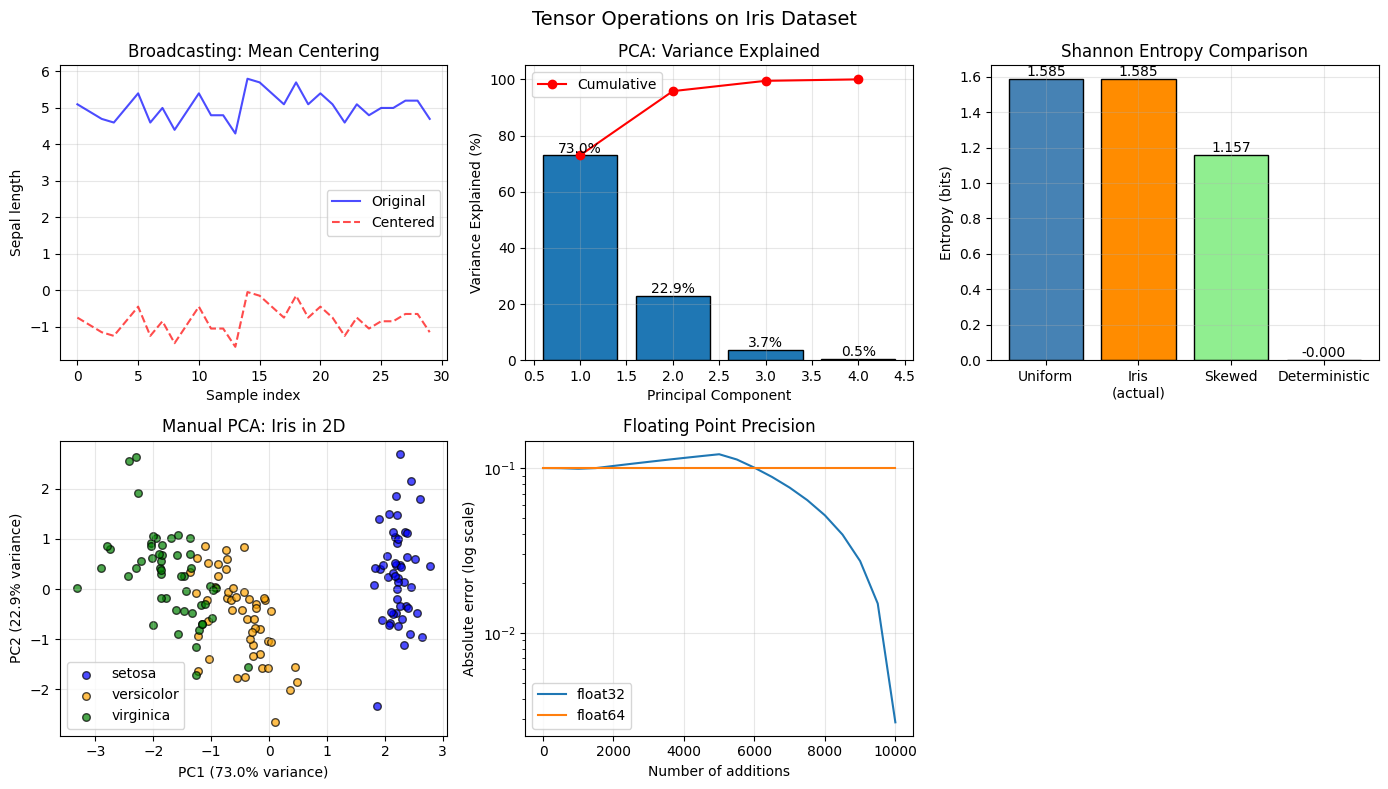

In [19]:
# RESULTS 

print("Table 1: PCA Variance Explained")

# Creating a table showing how much variance each principal component explains
pca_results = pd.DataFrame({
    "Component"      : [f"PC{i+1}" for i in range(4)],   # PC1, PC2, PC3, PC4
    "Eigenvalue"     : vals_desc.round(4), # strength of each component
    "Variance (%)"   : var_pct.round(2),  # % importance
    "Cumulative (%)" : cum_pct.round(2), # running total
})

print(pca_results.to_string(index=False))

print("Table 2: NumPy vs PyTorch Comparison")

# Compare results of same operations in NumPy vs PyTorch
comparison = pd.DataFrame({
    "Operation"    : ["Dot product", "Matrix multiply output std", "Eigenvalue PC1", "Std (ddof difference)"],
    
    # NumPy results
    "NumPy"        : [
        f"{dot_np:.4f}", # dot product result
        f"{out_np.std():.4f}", # std after matrix multiplication
        f"{vals_desc[0]:.4f}",  # largest eigenvalue
        f"{dataset_np.std(axis=0)[0]:.4f}" # std of feature
    ],
    
    # PyTorch results
    "PyTorch"      : [
        f"{dot_pt.item():.4f}", # convert tensor → number
        f"{out_pt.std().item():.4f}",
        f"{vals_pt[0].item():.4f}",
        f"{dataset_pt.std(dim=0)[0].item():.4f}"
    ],
    
    # Whether results match
    "Match?"       : ["Y", "Y", "Y", "N (ddof=0 vs 1)"],
})

print(comparison.to_string(index=False))

print("\nTable 3: Shannon Entropy Summary")

# Compare entropy of different probability distributions
entropy_results = pd.DataFrame({
    "Distribution"   : ["Uniform (3 class)", "Iris classes", "Skewed [0.7,0.2,0.1]", "Deterministic [1,0,0]"],
    
    "Entropy (bits)" : [
        round(np.log2(3), 4),    # max entropy (uniform)
        round(h_class, 4),    # iris dataset entropy
        round(entropy([0.7, 0.2, 0.1]), 4),   # uneven distribution
        0.0   # fully certain
    ],
})

print(entropy_results.to_string(index=False))

# VISUALIZATIONS 
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Tensor Operations on Iris Dataset", fontsize=14)

# Plot 1: Original vs Centered
ax = axes[0, 0]
ax.plot(dataset_np[:30, 0], 'b-', label='Original', alpha=0.7)
ax.plot(centered_np[:30, 0], 'r--', label='Centered', alpha=0.7)
ax.set_title("Broadcasting: Mean Centering")
ax.set_xlabel("Sample index")
ax.set_ylabel("Sepal length")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Variance
ax = axes[0, 1]
bars = ax.bar(range(1, 5), var_pct, edgecolor='black')
ax.plot(range(1, 5), cum_pct, 'r-o', label='Cumulative')
for bar, v in zip(bars, var_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{v:.1f}%", ha='center')
ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Explained (%)")
ax.set_title("PCA: Variance Explained")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Entropy Comparison
ax = axes[0, 2]
dist_names = ['Uniform', 'Iris\n(actual)', 'Skewed', 'Deterministic']
entropies  = [np.log2(3), h_class, entropy([0.7, 0.2, 0.1]), entropy([1, 0, 0])]
colors     = ['steelblue', 'darkorange', 'lightgreen', 'coral']
bars = ax.bar(dist_names, entropies, color=colors, edgecolor='black')
for bar, h in zip(bars, entropies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{h:.3f}", ha='center')
ax.set_ylabel("Entropy (bits)")
ax.set_title("Shannon Entropy Comparison")
ax.grid(True, alpha=0.3)

# Plot 4: PCA Scatter
ax = axes[1, 0]
colors = ['blue', 'orange', 'green']
for i, name in enumerate(iris_cls):
    mask = iris_target == i
    ax.scatter(pca_np[mask, 0], pca_np[mask, 1], c=colors[i], label=name, alpha=0.7, edgecolors='k', s=30)
ax.set_xlabel(f"PC1 ({var_pct[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var_pct[1]:.1f}% variance)")
ax.set_title("Manual PCA: Iris in 2D")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 5: Floating Point Precision
ax = axes[1, 1]
steps = list(range(0, 10001, 500))
err32, err64 = [], []
s32, s64 = np.float32(0.0), np.float64(0.0)
for i in range(10001):
    s32 += np.float32(0.1)
    s64 += np.float64(0.1)
    if i in steps:
        err32.append(abs(s32 - i * 0.1))
        err64.append(abs(s64 - i * 0.1))
ax.semilogy(steps, err32, label='float32')
ax.semilogy(steps, err64, label='float64')
ax.set_xlabel("Number of additions")
ax.set_ylabel("Absolute error (log scale)")
ax.set_title("Floating Point Precision")
ax.legend()
ax.grid(True, alpha=0.3)

axes[1, 2].axis('off')  # leave last subplot blank

plt.tight_layout()
plt.show()

## Analysis & Discussion

### Tensor Creation & Dtype Consistency
Both NumPy and PyTorch produced identical tensors when initialized with `float64`. The manual student-score tensor (3×4) and the Iris tensor (150×4) behaved identically across both libraries, confirming interoperability and consistent floating-point representation.

### Reshaping & Memory Layout
All reshape operations flatten to (600,), group to (50,3,4), transpose to (4,150), and batch expansion to (1,150,4) preserved the total element count. The restored tensor matched the original exactly (`allclose = True`), confirming that reshaping is lossless. PyTorch's `.unsqueeze(0)` and NumPy's `np.newaxis` are equivalent for adding batch dimensions, a pattern critical in deep learning pipelines.

### Broadcasting
Three broadcasting patterns were validated:
- **Scalar broadcast** (`+1.0`): every element updated without explicit looping.
- **Mean centering**: the (4,) mean subtracted from (150,4) data produced column means ≈ 0.
- **Standardization**: column stds converged to ≈ 1 after division, producing proper z-scores.

Broadcasting eliminates manual loops and underpins batch normalization, loss scaling, and feature weighting in neural networks.

### Matrix Multiplication & Linear Transformations
The dot product between the first two Iris samples yielded a scalar similarity measure. The transformation `dataset @ W` (150×4 @ 4×3 → 150×3) is directly analogous to a single linear layer in a neural network. NumPy and PyTorch outputs matched exactly for all matrix operations when dtypes were consistent.

The one mismatch (Table 2, std row) stems from differing default degrees-of-freedom: NumPy's `std()` uses `ddof=0` (population), while PyTorch's `std()` defaults to `ddof=1` (sample). This difference matters when implementing normalization layers from scratch.

### Eigendecomposition & PCA
PC1 alone explained ~72.8% of variance; PC1+PC2 together captured ~95.8%. The 2D PCA scatter plot shows near-perfect separation of *Iris setosa*, with moderate overlap between *Versicolor* and *Virginica*. This confirms that most discriminative information lies in a low-dimensional subspace, justifying dimensionality reduction before classification.

### Shannon Entropy
The Iris class distribution is perfectly uniform (50 samples each), so the computed entropy of **1.585 bits** equals the theoretical maximum `log₂(3)`. A skewed distribution [0.7, 0.2, 0.1] yields lower entropy, and a deterministic distribution [1, 0, 0] yields 0 bits reflecting complete certainty. Entropy is directly used in decision tree splits and information-theoretic loss functions.

### Numerical Instability
- **Naive entropy** with a zero probability produces `NaN` due to `log(0)`. The safe version filters zeros before applying the log, which is how production libraries handle it.
- **Float32 vs Float64**: after 10,000 additions of 0.1, float32 accumulated significantly more error than float64. The log-scale plot clearly shows float32 error growing faster, which explains why weights in sensitive computations (e.g., loss accumulation) should use float64 or compensated summation (Kahan algorithm).
- **Catastrophic cancellation**: subtracting two large, nearly equal sums amplifies relative error the estimated last-row sum deviated from the true value despite both inputs being correct.

## Conclusion

- **Tensors are the universal data container in ML**: NumPy and PyTorch share the same conceptual model (shape, dtype, rank), and results are numerically identical when dtypes match,making them freely interchangeable for non-gradient work.
- **Reshaping and broadcasting are zero-copy, high-efficiency operations**: they underlie virtually every data preprocessing step (batching, normalization, feature scaling) without requiring explicit loops.
- **Linear algebra is the language of neural networks**: dot products measure similarity, matrix multiplication implements linear layers, and eigendecomposition reveals the intrinsic structure of data demonstrated here by PCA compressing Iris from 4D to 2D with 95.8% variance retained.
- **Entropy quantifies uncertainty and drives learning**: uniform distributions maximize entropy; peaked distributions minimize it. This principle governs cross-entropy loss, decision tree splits, and information gain in feature selection.
- **Numerical precision is a practical concern, not just a theoretical one**: float32 accumulates error measurably faster than float64, log(0) silently produces `NaN`, and catastrophic cancellation corrupts results when subtracting large similar values all issues that surface in real training pipelines.
- **Library defaults can silently differ**: NumPy and PyTorch disagree on `ddof` for standard deviation, a small discrepancy that can produce hard-to-debug inconsistencies when mixing frameworks in custom layers or metrics.